# Production Pipeline

> This notebook shows the complete of the workflow of the OCR pipeline, and reflects the behavior of the developed API.

An input snapshot of the score card is registered to a defined template of the same card, to extract cells of the score table with hand written digits. The extracted cell images are passed through a fine-tuned Resnet-18 for classification.

Since the v2 pipeline:
- The image registration module is now orientation invariant, inputs must be aproximately oriented upright.
- Generalization of several surrounding functions (especially in grids), to accomodate multiple template types.

In the final output grid of images and their associated prediction, those with a confidence score of less than 0.90 are highlighted in red, and those between 0.90 and 0.95 are highlighted in blue.

In [4]:
import numpy as np
import cv2
import os, sys
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from skimage import io, filters, color
from pathlib import Path
import pickle as pkl

PROJECT_ROOT = Path().resolve().parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))
MODELS_DIR = PROJECT_ROOT / "models"
sys.path.insert(0, str(MODELS_DIR))

temp_path = "..\\data\\Templates"
data_path = "..\\data\\Data2"
rawdata_path = "..\\data\\Data2\\Raw"
newdata_path = "..\\data\\Data2\\New"
regdata_path = "..\\data\\Data2\\Registered"

with open(PROJECT_ROOT / "APIs" / "templates.pkl", 'rb') as f:
    templates = pkl.load(f)

In [5]:
def load_img(img_f, img_dir=temp_path, h_points=None, s_points=None, show=False):
    """
    h_points : header points
    s_points : score points
    """
    img_p = os.path.join(img_dir, f"{img_f}.jpeg")
    i = Image.open(img_p)
    i = ImageOps.exif_transpose(i)
    i = np.array(i)
    if i is None: raise ValueError("Image not found or unable to load.")
    if show:
        show_points(i, h_points, s_points)
    return i

def show_points(i, h_points, s_points):

    plt.figure(figsize=(8, 6))
    plt.imshow(i)
    if h_points is None: 
        h_points = np.array([])
    else: 
        h_points = np.array(h_points)
        plt.scatter(h_points[:, 0], h_points[:, 1], c='red', s=8)
    if s_points is None: 
        s_points = np.array([])
    else: 
        s_points = np.array(s_points)
        for block in s_points:
            plt.scatter(block[:, 0], block[:, 1], c='red', s=8)
        
    plt.axis('off')
    plt.show()

In [18]:
def get_grid_from_block(block):
    """
    Get a grid from a block of coordinates.
    """
    # block shape: (10, 5, 2)
    block = np.asarray(block)

    x_coords = np.unique(block[:, 0]).astype(int)
    y_coords = np.unique(block[:, 1]).astype(int)

    return np.sort(x_coords), np.sort(y_coords)

def crop_cells_grid(img, x_coords, y_coords, target_h=28, pad=0):
    grid = []

    for i in range(len(y_coords) - 1):
        row = []
        for j in range(len(x_coords) - 1):
            x1, x2 = x_coords[j] - pad, x_coords[j+1] + pad
            y1, y2 = y_coords[i] - pad, y_coords[i+1] + pad

            cell = img[y1:y2, x1:x2]
            # resize to target height
            h, w = cell.shape[:2]
            scale = target_h / h
            new_w = max(1, int(w * scale))

            cell_resized = cv2.resize(cell, (new_w, target_h), interpolation=cv2.INTER_AREA)
            row.append(cell_resized)
        grid.append(row)

    return grid

def crop_blocked_grid(img, score_cells, target_h=28, pad=0):
    """
    Crop each blocks of score cells.
    """
    grids = []
    for block in score_cells:
        x_coords, y_coords = get_grid_from_block(block)
        grids.append(crop_cells_grid(img, x_coords, y_coords, target_h, pad))
    return grids

def invariance(samp, temp, size_th=5, orient_th=3, d_ratio=0.7):

    sift = cv2.SIFT_create()
    kpT = sift.detect(temp, None)
    kpS = sift.detect(samp, None)
    kpS = [k for k in kpS if k.size > size_th]
    kpT = [k for k in kpT if k.size > size_th]
    for k in kpS: k.angle = 0
    for k in kpT: k.angle = 0

    desT = sift.compute(temp, kpT)[1]
    desS = sift.compute(samp, kpS)[1]
    matcher = cv2.FlannBasedMatcher()
    matches = matcher.knnMatch(desT, desS, k=2)
    filtered = [m for m,n in matches if m.distance < d_ratio*n.distance]

    points_temp = np.float32([kpT[m.queryIdx].pt for m in filtered])
    points_samp = np.float32([kpS[m.trainIdx].pt for m in filtered])

    return points_temp, points_samp, kpT, kpS, filtered

def register_image(samp, template):

    temp = template.get('image')
    crease_x = template.get('crease_x')

    points_temp, points_samp, kpT, kpS, filtered = invariance(samp, temp)

    height, width = temp.shape[:2]
    left_mask = points_temp[:, 0] < crease_x
    right_mask = points_temp[:, 0] >= crease_x
    reg_img = np.zeros_like(temp)

    matched_inliers = []
    left_inliers, right_inliers = 0, 0

    for mask, x_range, side in [(left_mask, (0, crease_x), "L"), (right_mask, (crease_x, width), "R")]:
        if np.sum(mask) < 4: continue
        
        # Rigidly align just this half
        H, inlier_mask = cv2.findHomography(points_samp[mask], points_temp[mask], cv2.RANSAC, 5.0)
        warped = cv2.warpPerspective(samp, H, (width, height))
        
        # Stitch into final image
        x1, x2 = x_range
        reg_img[:, x1:x2] = warped[:, x1:x2]

        idx = np.where(mask)[0]
        for i, keep in zip(idx, inlier_mask.ravel()):
            if keep: matched_inliers.append(filtered[i])

        if side == "L":   left_inliers = int(inlier_mask.sum())
        else:             right_inliers = int(inlier_mask.sum())
    
    matched_img = cv2.drawMatches(temp, kpT, samp, kpS, matched_inliers, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    return reg_img, matched_img

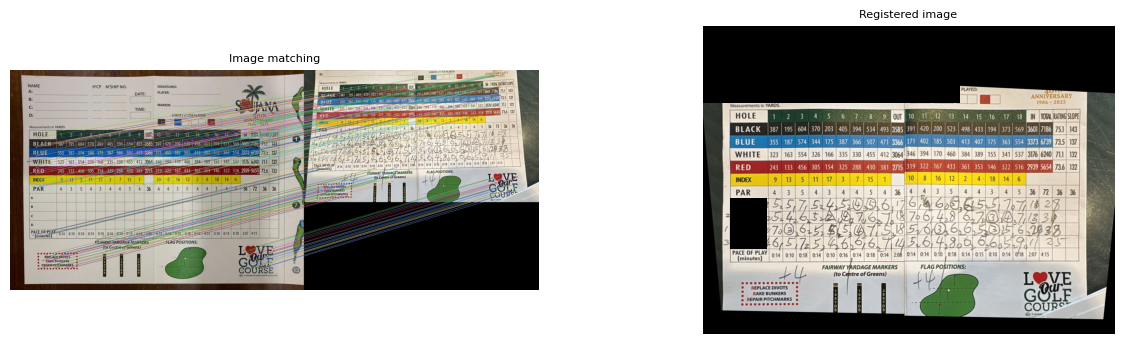

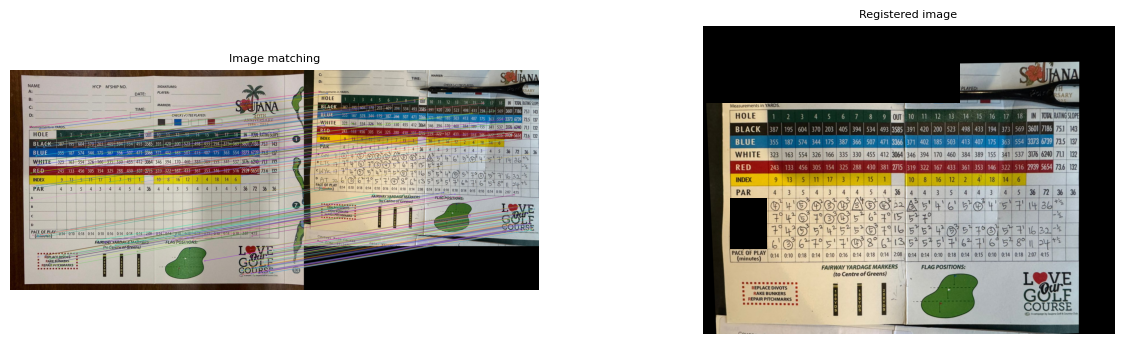

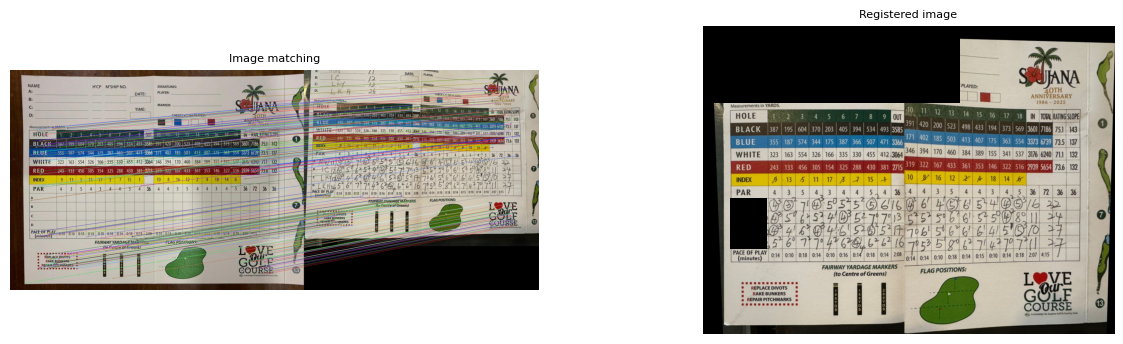

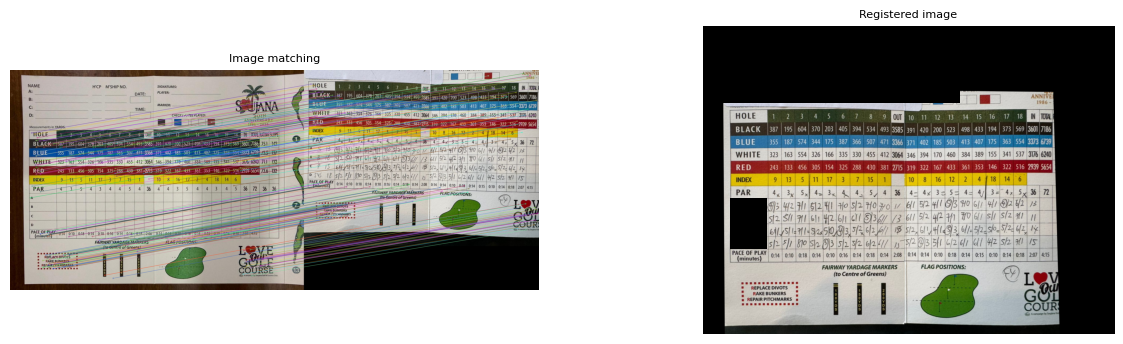

In [15]:
template = templates['Data2']
rect2_init = template['header'][0]
rect2_width = template['header'][-1][0] - template['header'][0][0] - 6
rect2_height = template['header'][-1][1] - template['header'][0][1]
for i in range(0,4):
    test_image = f"image_{i}"
    test_i = load_img(test_image, img_dir=newdata_path)
    registered_i, matched_i = register_image(test_i, template)
    mask_rect1 = plt.Rectangle((0, 0), 1000, 300, edgecolor=None, facecolor='black', linewidth=0)
    mask_rect2 = plt.Rectangle(rect2_init, rect2_width, rect2_height, edgecolor=None, facecolor='black', linewidth=0)
    fig, ax = plt.subplots(1, 2, figsize=(15,4))
    ax = ax.flatten()
    ax[0].imshow(matched_i)
    ax[0].set_title('Image matching', fontsize=8)
    ax[1].imshow(registered_i)
    ax[1].add_patch(mask_rect1)
    ax[1].add_patch(mask_rect2)
    ax[1].set_title('Registered image', fontsize=8)
    for a in ax: a.axis('off')

In [20]:
from resnet18 import RESNET18
import torchvision.transforms as T
import torch

infer_transform = T.Compose([
    T.Resize((64, 64)),
    T.Grayscale(num_output_channels=1),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

weights_path = "..\\weights"
resnet_version = "resnet18_v1"
model = RESNET18(num_classes=10)
state_dict = torch.load(os.path.join(weights_path, resnet_version, "resnet_real_train_v1.pth"), map_location=model.device, weights_only=True)
model.load_state_dict(state_dict['model_state'])

<All keys matched successfully>

In [31]:
# TODO: add threshold for low-confidence predictions
def recognize_scorecard(grid, model, transform):
    model.eval()

    rows, cols = len(grid), len(grid[0])

    # Flatten grid
    flat_cells = [cell for row in grid for cell in row]

    # Apply transform
    tensors = [transform(Image.fromarray(cell)) for cell in flat_cells]

    # Stack into ONE batch
    batch = torch.stack(tensors).to(model.device)  # (72, C, H, W)

    with torch.no_grad():
        probs, logits = model(batch)
        preds = torch.argmax(logits, dim=1)
        confs = torch.max(probs, dim=1).values
        confs = confs.cpu().numpy()
        preds = preds.cpu().numpy()

    # Reshape back to grid
    preds_grid = preds.reshape(rows, cols)
    confs_grid = confs.reshape(rows, cols)
    result_grid = [[{"row": i, "col": j, "digit": int(preds_grid[i][j]), "confidence": float(confs_grid[i][j])}
                    for j in range(cols)]
                    for i in range(rows)]
    
    return result_grid

def normalize_grids(grid, target_rows):
    if len(grid) == target_rows:      return grid
    if len(grid[0]) == target_rows:   return [list(row) for row in zip(*grid)]

def result_vis(header_grid, score_grid, show_header=True, header_preds=None, score_preds=None):
    # 1. Prepare data
    full_display_grid = []
    if show_header:
        for h_row, s_row in zip(header_grid, score_grid):
            full_display_grid.append([h_row[0]] + s_row)
    else:
        full_display_grid = score_grid
        header_preds = None

    # 2. Determine grid dimensions
    num_rows = len(full_display_grid)
    num_cols = len(full_display_grid[0]) if num_rows > 0 else 0

    # 3. Create the subplot figure
    _, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 1))

    # 4. Fill the subplots
    for r in range(num_rows):
        for c in range(num_cols):
            ax = axes[r, c] if num_rows > 1 else axes[c]
            cell_img = full_display_grid[r][c]
            ax.imshow(cell_img, cmap='gray')

            if c == 0 and show_header:            # header cells titles
                if header_preds:
                    cell = header_preds[r][0]
                    p, c = cell['digit'], cell['confidence']
                    ax.set_title(f"{p} ({c:.3f})", fontsize=14)
            else:
                if score_preds:   # score cells titles
                    pred_col = c - 1 if show_header else c
                    cell = score_preds[r][pred_col]
                    pred, conf = cell['digit'], cell['confidence']
                    if conf <= 0.95:
                        for spine in ax.spines.values():
                            if conf < 0.9: spine.set_edgecolor('red')
                            else: spine.set_edgecolor('blue')
                            spine.set_linewidth(2)
                    ax.set_title(f"{pred} ({conf:.3f})", fontsize=14)
            ax.set_xticks([])
            ax.set_yticks([])
            
    plt.subplots_adjust(wspace=0.02, hspace=0.5)

def infer_scorecard(img, template, model, transform, show_header=False):
    test_i = load_img(img, img_dir=newdata_path)
    # test_i = preprocess(test_i)
    registered_i, _ = register_image(test_i, template)
    score_grids = crop_blocked_grid(registered_i, template.get('score'), target_h=48, pad=4)
    header_grid = crop_cells_grid(registered_i, *get_grid_from_block(template.get('header')), target_h=48, pad=4)
    norm_score_grids = [normalize_grids(grid, len(header_grid)) for grid in score_grids]
    merged_sg = []
    for rows in zip(*norm_score_grids):
        merged_sg.append([cell for row in rows for cell in row])
    s_preds = recognize_scorecard(merged_sg, model, transform)
    results_view = result_vis(header_grid=header_grid, score_grid=merged_sg, score_preds=s_preds, show_header=show_header)
    return results_view

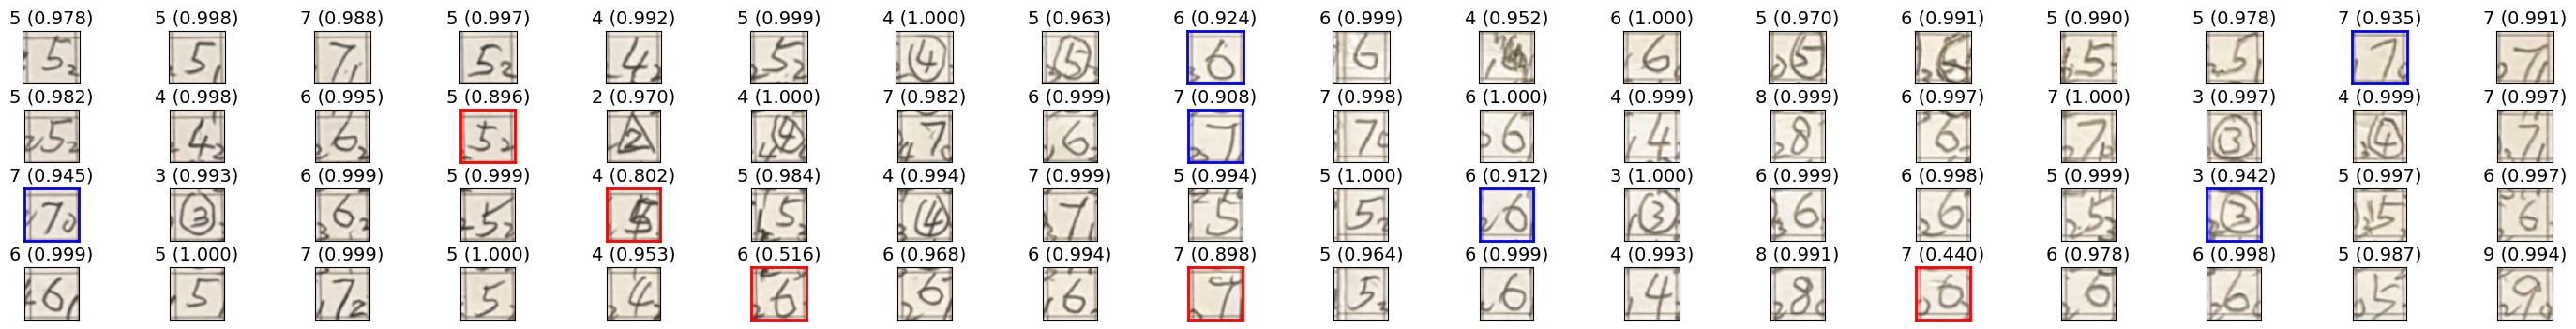

In [32]:
test_image = "image_0"
infer_scorecard(test_image, template, model, infer_transform)

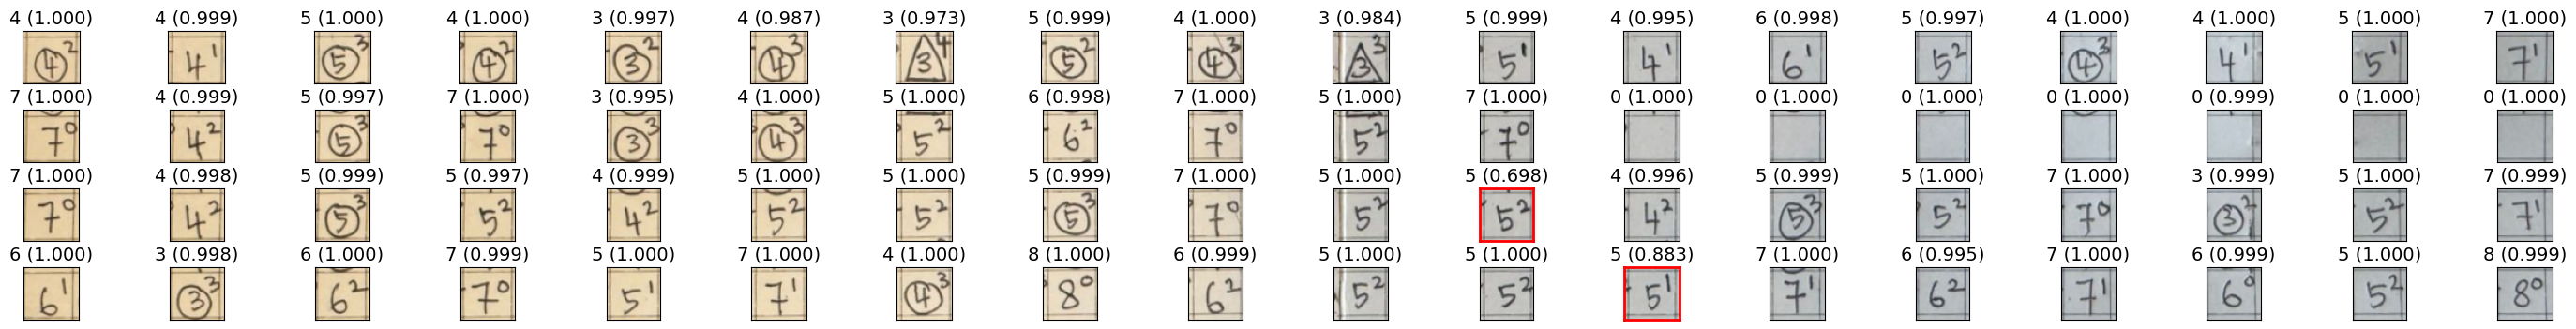

In [33]:
test_image = "image_1"
infer_scorecard(test_image, template, model, infer_transform)

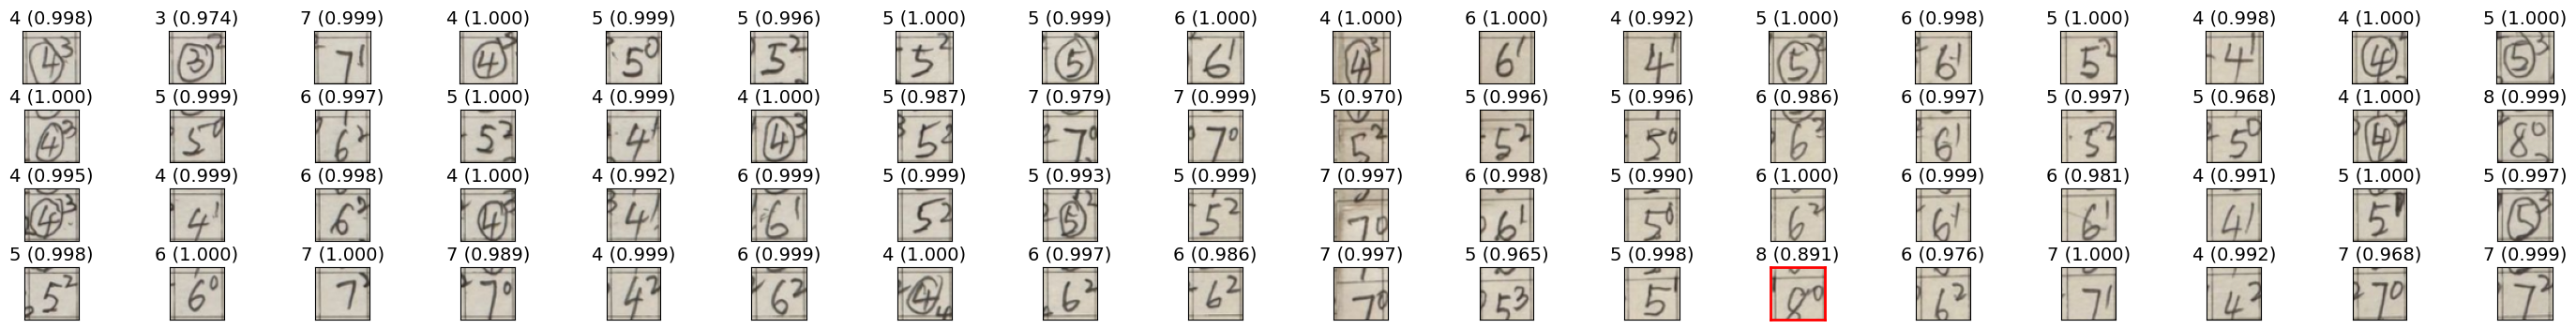

In [34]:
test_image = "image_2"
infer_scorecard(test_image, template, model, infer_transform)

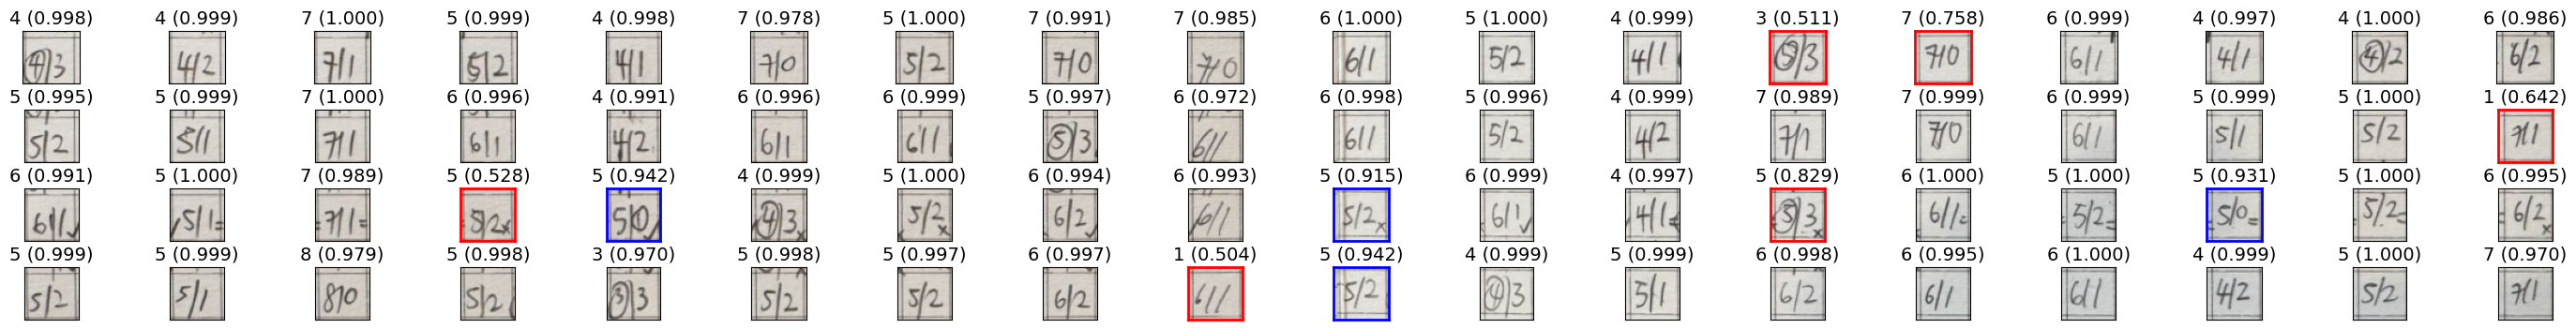

In [35]:
test_image = "image_3"
infer_scorecard(test_image, template, model, infer_transform)